# Apple Data Analytics
## Question 1: Product Reliability & The Cost of Quality

In [2]:
# Core query engine — reads CSVs directly, no in-memory loading
import duckdb

# Holds small aggregated result sets returned from DuckDB
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Create an in-process DuckDB connection
con = duckdb.connect()

# Register each CSV as a view — DuckDB scans the file on demand,
# nothing is loaded into Python memory at this point
con.execute("CREATE VIEW sales    AS SELECT * FROM read_csv_auto('sales.csv')")
con.execute("CREATE VIEW warranty AS SELECT * FROM read_csv_auto('warranty.csv')")
con.execute("CREATE VIEW products AS SELECT * FROM read_csv_auto('products.csv')")
con.execute("CREATE VIEW category AS SELECT * FROM read_csv_auto('category.csv')")
con.execute("CREATE VIEW stores   AS SELECT * FROM read_csv_auto('stores.csv')")

print("Views registered successfully")

Views registered successfully


In [ ]:
# Verify column names and data types before writing queries
con.execute("SELECT * FROM category LIMIT 5").df()

,category_id,category_name
0,CAT-1,Laptop
1,CAT-2,Audio
2,CAT-3,Tablet
3,CAT-4,Smartphone
4,CAT-5,Wearable


In [ ]:
# Confirm expected number of categories (should be 10)
con.execute("SELECT COUNT(*) AS total_rows_category FROM category").df()

,total_rows_category
0,10


In [24]:
# Checking for any null values in category.csv
con.execute("SELECT COUNT(*) AS num_null_values_category FROM category WHERE category_id IS NULL OR category_name IS NULL").df()

,num_null_values_category
0,0


In [29]:
# Checking potential duplicate category IDs in column 'category_id' in category.csv
con.execute("SELECT category_id, COUNT(*) AS duplicate_id_count_category FROM category GROUP BY category_id HAVING COUNT(*)>1").df()


,category_id,duplicate_id_count_category


In [ ]:
# Spotted uppercase column names — need to fix before querying
con.execute("SELECT * FROM stores LIMIT 5").df()

,Store_ID,Store_Name,City,Country
0,ST-1,Apple Fifth Avenue,New York,United States
1,ST-2,Apple Union Square,San Francisco,United States
2,ST-3,Apple Michigan Avenue,Chicago,United States
3,ST-4,Apple The Grove,Los Angeles,United States
4,ST-5,Apple SoHo,New York,United States


In [ ]:
# Confirm store count for scale awareness
con.execute("SELECT COUNT(*) AS total_rows_stores FROM stores").df()

,total_rows_stores
0,75


In [28]:
# Checking for any null values in stores.csv
con.execute("SELECT COUNT(*) AS num_null_values_stores FROM stores WHERE Store_ID IS NULL OR Store_Name IS NULL OR  City IS NULL OR Country IS NULL").df()

,num_null_values_stores
0,0


In [40]:
# making all column names in stores.csv lower case 
con.execute("DROP VIEW stores")
con.execute("CREATE VIEW stores AS SELECT Store_ID AS store_id, Store_Name AS store_name, City AS city, Country AS country FROM read_csv_auto('stores.csv')")

In [41]:
# checking to see whether column names in stores.csv are all lower case
con.execute("SELECT * FROM stores LIMIT 5").df()

,store_id,store_name,city,country
0,ST-1,Apple Fifth Avenue,New York,United States
1,ST-2,Apple Union Square,San Francisco,United States
2,ST-3,Apple Michigan Avenue,Chicago,United States
3,ST-4,Apple The Grove,Los Angeles,United States
4,ST-5,Apple SoHo,New York,United States


In [ ]:
# Checking potential duplicate store IDs in columns 'store_id' in store.csv
con.execute("SELECT store_id, COUNT(*) AS duplicate_id_count_stores FROM stores GROUP BY store_id HAVING COUNT(*)>1").df()

,store_id,duplicate_id_count_stores


In [ ]:
# Verify column names and data types — uppercase columns need renaming
con.execute("SELECT * FROM products LIMIT 5").df()

,Product_ID,Product_Name,Category_ID,Launch_Date,Price
0,P-1,MacBook,CAT-1,2023-09-17,1149
1,P-2,MacBook Air (M1),CAT-1,2023-11-11,1783
2,P-3,MacBook Air (M2),CAT-1,2020-05-24,1588
3,P-4,MacBook Pro 13-inch,CAT-1,2021-01-17,1351
4,P-5,MacBook Pro 14-inch,CAT-1,2024-05-12,768


In [ ]:
# Confirm product count (should be ~89)
con.execute("SELECT COUNT(*) AS total_rows_products FROM products").df()

,total_rows_products
0,89


In [35]:
# Checking for any null values in products.csv
con.execute("SELECT COUNT(*) AS num_null_values_products FROM products WHERE Product_ID IS NULL OR Product_Name IS NULL OR Category_ID IS NULL OR Launch_Date IS NULL OR Price IS NULL").df()

,num_null_values_products
0,0


In [44]:
# making all column names in products.csv lower case 
con.execute("CREATE VIEW products AS SELECT Product_ID AS product_id, Product_Name AS product_name, Category_ID AS category_id, Launch_Date AS launch_date, Price AS price FROM read_csv_auto('products.csv')")

In [45]:
# checking whether all columns in 'products.csv' are all lower case 
con.execute("SELECT * FROM products LIMIT 5").df()

,product_id,product_name,category_id,launch_date,price
0,P-1,MacBook,CAT-1,2023-09-17,1149
1,P-2,MacBook Air (M1),CAT-1,2023-11-11,1783
2,P-3,MacBook Air (M2),CAT-1,2020-05-24,1588
3,P-4,MacBook Pro 13-inch,CAT-1,2021-01-17,1351
4,P-5,MacBook Pro 14-inch,CAT-1,2024-05-12,768


In [ ]:
# Checking potential duplicate product IDs in columns 'product_id' in products.csv
con.execute("SELECT product_id, COUNT(*) AS duplicate_id_count_products FROM products GROUP BY product_id HAVING COUNT(*)>1").df()

,product_id,duplicate_id_count_products


In [ ]:
# Verify structure — sales is the main denominator in all claim rate calculations
con.execute("SELECT * FROM sales LIMIT 5").df()

,sale_id,sale_date,store_id,product_id,quantity
0,YG-8782,2023-06-16,ST-10,P-38,10
1,QX-999001,2022-04-13,ST-63,P-48,10
2,JG-46890,2021-07-05,ST-26,P-79,5
3,XJ-1731,2022-07-20,ST-15,P-24,9
4,FG-95080,2022-03-18,ST-35,P-69,7


In [ ]:
# 1M+ rows confirms scale — DuckDB needed for performance
con.execute("SELECT COUNT(*) AS total_rows_sales FROM sales").df()

,total_rows_sales
0,1040200


In [49]:
# Checking for any null values in sales.csv
con.execute("SELECT COUNT(*) AS num_null_values_sales FROM sales WHERE sale_id IS NULL OR sale_date IS NULL OR store_id IS NULL OR product_id IS NULL OR quantity IS NULL").df()

,num_null_values_sales
0,0


In [50]:
# Checking potential duplicate sales IDs in columns 'sale_id' in sales.csv
con.execute("SELECT sale_id, COUNT(*) AS duplicate_id_count_sales FROM sales GROUP BY sale_id HAVING COUNT(*)>1").df()

,sale_id,duplicate_id_count_sales


In [ ]:
# Guard against invalid sales data that would inflate total units sold
con.execute("SELECT COUNT(*) AS invalid_quantity_count_sales FROM sales WHERE quantity<1").df()

,invalid_quantity_count_sales
0,0


In [ ]:
# Inspect repair_status values before filtering on them
con.execute("SELECT * FROM warranty LIMIT 5").df()

,claim_id,claim_date,sale_id,repair_status
0,CL-58750,2024-01-30,YG-8782,Completed
1,CL-8874,2024-06-25,QX-999001,Pending
2,CL-14486,2024-08-13,JG-46890,Pending
3,CL-42187,2024-09-19,XJ-1731,Pending
4,CL-37590,2024-09-16,FG-95080,Completed


In [ ]:
# 30K claims across 1M+ sales confirms low overall claim rate
con.execute("SELECT COUNT(*) AS total_rows_warranty FROM warranty").df()

,total_rows_warranty
0,30000


In [55]:
# Checking for any null values in warranty.csv
con.execute("SELECT COUNT(*) AS num_null_values_warranty FROM warranty WHERE claim_id IS NULL OR claim_date IS NULL OR sale_id IS NULL OR repair_status IS NULL ").df()

,num_null_values_warranty
0,0


In [56]:
# Checking potential duplicate claim IDs in columns 'claim_id' in warranty.csv
con.execute("SELECT claim_id, COUNT(*) AS duplicate_id_count_claim FROM warranty GROUP BY claim_id HAVING COUNT(*)>1").df()

,claim_id,duplicate_id_count_claim


In [60]:
# Checking repair statuses in columns 'repair_status' in warranty.csv
con.execute("SELECT DISTINCT repair_status FROM warranty").df()

,repair_status
0,Pending
1,Rejected
2,Completed


In [59]:
# merging 'Pending' and 'In Progress' repair_status into one repair_status 'Pending'
con.execute("DROP VIEW IF EXISTS warranty")
con.execute("CREATE VIEW warranty AS SELECT claim_id, sale_id, CASE WHEN repair_status = 'In Progress' THEN 'Pending' ELSE repair_status END AS repair_status FROM read_csv_auto('warranty.csv')")

In [ ]:
# Query 1 — Claim rate by category (broadest view, one row per category)
df_category_claims = con.execute("SELECT category_name, COUNT(claim_id) AS total_claims, SUM(quantity) AS total_units_sold, ROUND(COUNT(claim_id) * 100.0 / SUM(quantity), 2) AS claim_rate_pct FROM sales LEFT JOIN warranty ON sales.sale_id = warranty.sale_id LEFT JOIN products ON sales.product_id = products.product_id LEFT JOIN category ON products.category_id = category.category_id GROUP BY category_name ORDER BY claim_rate_pct DESC").df()

In [ ]:
# Query 2 — Drill down to product level to find specific high-claim models
df_product_claims = con.execute("SELECT product_name AS product_name, COUNT(claim_id) AS total_claims, SUM(quantity) AS total_units_sold, ROUND(COUNT(claim_id) * 100.0 / SUM(quantity), 2) AS claim_rate_pct FROM sales LEFT JOIN warranty ON sales.sale_id = warranty.sale_id LEFT JOIN products ON sales.product_id = products.product_id LEFT JOIN category ON products.category_id = category.category_id GROUP BY product_name ORDER BY claim_rate_pct DESC").df()

In [ ]:
# Query 3 — Regional rejection rate (% of claims rejected per country)
df_regional_rejection = con.execute("SELECT country AS country, COUNT(claim_id) AS total_claims, COUNT(CASE WHEN repair_status = 'Rejected' THEN 1 END) AS rejected_claims, ROUND(COUNT(CASE WHEN repair_status = 'Rejected' THEN 1 END) * 100.0 / COUNT(claim_id), 2) AS rejection_rate_pct FROM warranty LEFT JOIN sales ON sales.sale_id = warranty.sale_id LEFT JOIN stores ON sales.store_id = stores.store_id GROUP BY country ORDER BY rejection_rate_pct DESC").df()

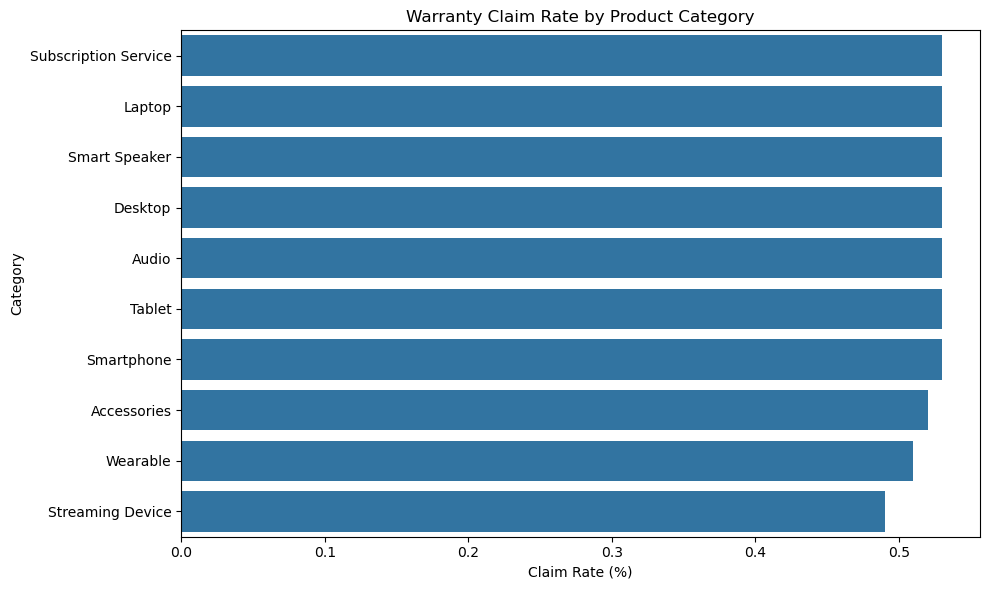

In [ ]:
# plotting Query 1 (top 10 product categories by warranty claim rate)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_category_claims, x='claim_rate_pct', y='category_name')
plt.title('Warranty Claim Rate by Product Category')
plt.xlabel('Claim Rate (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

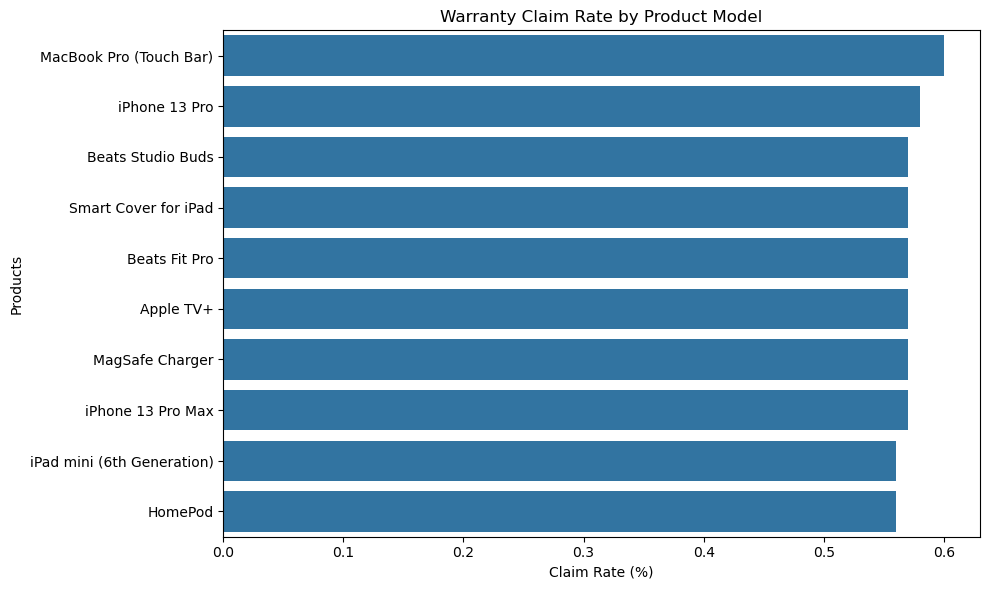

In [27]:
# plotting Query 2 (top 10 products by warranty claim rate)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_product_claims.head(10), x='claim_rate_pct', y='product_name', orient = 'h')
plt.title('Warranty Claim Rate by Product Model')
plt.xlabel('Claim Rate (%)')
plt.ylabel('Products')
plt.tight_layout()
plt.show()

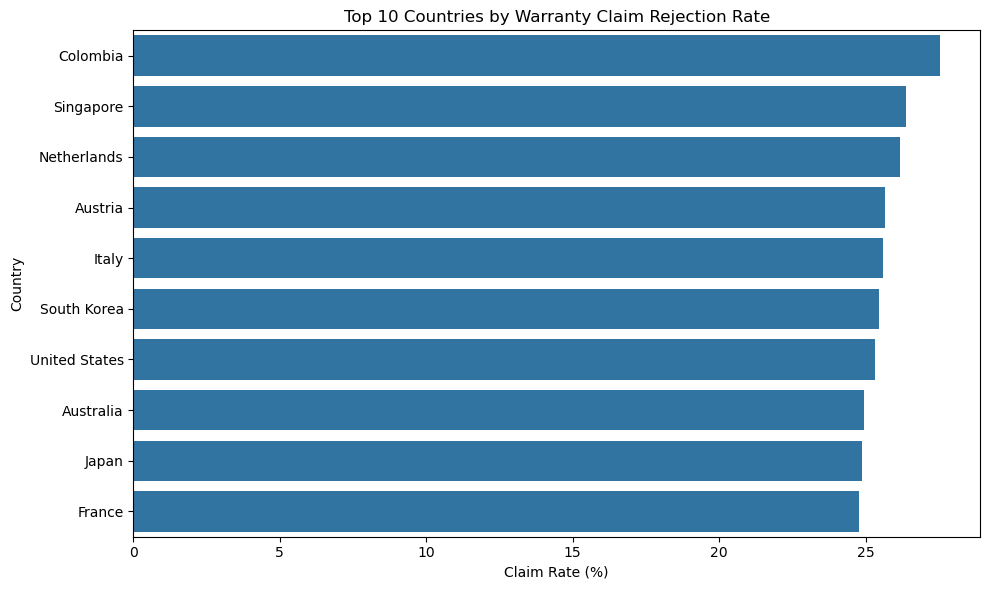

In [31]:
# plotting Query 3 (top 10 countries by warranty claim rate)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_regional_rejection.head(10), x='rejection_rate_pct', y='country')
plt.title('Top 10 Countries by Warranty Claim Rejection Rate')
plt.xlabel('Claim Rate (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [ ]:
## Business Question 1: Key Findings

### Query 1 — Warranty Claim Rate by Category
Warranty claim rates are nearly identical across all 10 product categories, ranging from **0.49% to 0.53%**. No single category stands out as dramatically worse than others. The top categories by claim rate were **Subscription Service, Laptop, and Smart Speaker**, all tied at **0.53%**. While claim rates are uniform, **Smartphones and Accessories** have the highest absolute claim counts due to higher sales volume.

### Query 2 — Warranty Claim Rate by Product Model
At the product level, specific models emerge as outliers. The top offenders by claim rate were:
- **MacBook Pro (Touch Bar)** — 0.60%
- **iPhone 13 Pro** — 0.58%
- **Beats Studio Headphones** — 0.57%

Notably, multiple iPhone models appear in the top offenders, suggesting a potential quality issue across iPhone generations rather than a one-off defect in a single model.

### Query 3 — Regional Rejection Rate
Rejection rates vary meaningfully across regions. The top 5 countries with the highest warranty claim rejection rates were:
- **Colombia** — 27.53%
- **Singapore** — 26.38%
- **Netherlands** — 26.17%
- **Austria** — 25.67%
- **Italy** — 25.60%

The geographic spread across South America, Asia, and Europe suggests the rejections are not driven by a single regional policy. Apple's claims processing teams in these regions may warrant a consistency review.

### Summary
While overall claim rates are low and consistent across categories, the product-level analysis reveals specific models — particularly MacBook Pro (Touch Bar) and multiple iPhone generations — that generate disproportionately high claim rates. Combined with above-average rejection rates in certain regions, this analysis highlights both product quality and claims processing consistency as areas for Apple to investigate.